# PPE: Last Millennium Reanalysis

In [1]:
%load_ext autoreload
%autoreload 2

import os
os.chdir('/glade/work/fengzhu/GitHub/cfr/docsrc/v2026/notebooks')
import pandas as pd
import xarray as xr
import xesmf as xe
import numpy as np
import cfr
cfr.use('v2026')
print(cfr.__version__)

2026.4.8


## Pseudoproxies Setup

In [23]:
df_raw = pd.read_json('https://github.com/fzhu2e/cfr-data/raw/refs/heads/main/pages2kv2.json')
df = df_raw.rename(columns={
    'paleoData_pages2kID': 'pid',
    'geo_meanLat': 'lat',
    'geo_meanLon': 'lon',
    'archiveType': 'archive',
})[['pid', 'lat', 'lon', 'archive']]

# mask = df['archive'].isin(['marine sediment', 'coral', 'sclerosponge', 'bivalve'])
# obs = cfr.Obs(df[mask])
obs = cfr.Obs(df)
obs.df['time'] = object
obs.df['value'] = object

In [2]:
dirpath = '/glade/work/fengzhu/Data/GCM_sims'
ds_prior = xr.open_dataset(os.path.join(dirpath, 'CCSM4', 'tas_sfc_Amon_CCSM4_past1000_085001-185012.nc'))
ds_truth = xr.open_dataset(os.path.join(dirpath, 'iCESM', 'LM', 'tas_sfc_Amon_iCESM_past1000historical_085001-200512.nc'))

ds_truth_ann = ds_truth.x.annualize(time2year=True) - 273.15
ds_truth_ann['tas'].attrs['units'] = 'degC'

ds_prior = ds_prior.drop_vars(['lat_bnds', 'lon_bnds', 'height'])
ds_prior_ann = ds_prior.x.annualize(time2year=True) - 273.15
ds_prior_ann['tas'].attrs['units'] = 'degC'

regridder = xe.Regridder(ds_prior_ann, ds_truth_ann, method='bilinear')
ds_prior_ann = regridder(ds_prior_ann)
ds_prior_ann['tas'].attrs = ds_truth_ann['tas'].attrs

In [24]:
# a simple white noise model without data attrition
SNR = 10   # var(signal) / var(noise)
for idx, row in obs.df.iterrows():
    np.random.seed(idx)
    obs.df.at[idx, 'time'] = np.arange(850, 2006)
    obs.df.at[idx, 'SNR'] = SNR
    signal = ds_truth_ann.sel(
        lat=row['lat'],
        lon=row['lon'],
        method='nearest',
    ).tas.values
    signal_var = np.var(signal, ddof=1)
    noise_var = signal_var / SNR
    obs.df.at[idx, 'R'] = noise_var
    noise = np.random.normal(loc=0, scale=np.sqrt(noise_var), size=signal.shape)
    obs.df.at[idx, 'value'] = signal + noise

obs.df['type'] = 'T'
obs.df['psm_name'] = 'IdenticalTS'
obs.df

,pid,lat,lon,archive,time,value,SNR,R,type,psm_name
0,NAm_153,52.70,241.70,tree,"[850, 851, 852, 853, 854, 855, 856, 857, 858, ...","[-0.02292751859725406, 0.3572480420356854, 0.7...",10.0,0.089662,T,IdenticalTS
1,Asi_245,23.00,114.00,documents,"[850, 851, 852, 853, 854, 855, 856, 857, 858, ...","[21.125607818090135, 20.116943803724595, 19.96...",10.0,0.021568,T,IdenticalTS
2,NAm_165,37.90,252.30,tree,"[850, 851, 852, 853, 854, 855, 856, 857, 858, ...","[6.338173780630901, 7.4904591259960585, 6.8232...",10.0,0.065712,T,IdenticalTS
3,Asi_178,28.77,83.73,tree,"[850, 851, 852, 853, 854, 855, 856, 857, 858, ...","[7.1370074286774425, 5.966696792272471, 6.3234...",10.0,0.046389,T,IdenticalTS
4,Asi_174,28.18,85.43,tree,"[850, 851, 852, 853, 854, 855, 856, 857, 858, ...","[10.911502987956526, 10.585710012500336, 10.76...",10.0,0.013729,T,IdenticalTS
...,...,...,...,...,...,...,...,...,...,...
687,Asi_201,35.88,74.18,tree,"[850, 851, 852, 853, 854, 855, 856, 857, 858, ...","[-4.287775723319058, -4.232198470857572, -3.74...",10.0,0.047043,T,IdenticalTS
688,Asi_179,27.50,88.02,tree,"[850, 851, 852, 853, 854, 855, 856, 857, 858, ...","[7.563148014053656, 7.277179376837475, 7.47118...",10.0,0.019030,T,IdenticalTS
689,Arc_014,63.62,29.10,lake sediment,"[850, 851, 852, 853, 854, 855, 856, 857, 858, ...","[-1.0157051133439026, -0.25941108796600443, 1....",10.0,0.212980,T,IdenticalTS
690,Ocn_071,16.20,298.51,coral,"[850, 851, 852, 853, 854, 855, 856, 857, 858, ...","[25.283580513311232, 24.776707927084082, 24.91...",10.0,0.012692,T,IdenticalTS


In [25]:
np.unique(obs.df['archive'])

array(['bivalve', 'borehole', 'coral', 'documents', 'glacier ice',
       'hybrid', 'lake sediment', 'marine sediment', 'sclerosponge',
       'speleothem', 'tree'], dtype=object)

In [26]:
os.makedirs('./data', exist_ok=True)
obs.df.to_json('./data/df_proxy_ocn.json')
df_ocn = pd.read_json('./data/df_proxy_ocn.json')
print(type(df_ocn.loc[0, 'time']))
print(type(df_ocn.loc[0, 'value']))
df_ocn

<class 'list'>
<class 'list'>


,pid,lat,lon,archive,time,value,SNR,R,type,psm_name
0,NAm_153,52.70,241.70,tree,"[850, 851, 852, 853, 854, 855, 856, 857, 858, ...","[-0.022927518600000002, 0.35724804200000004, 0...",10,0.089662,T,IdenticalTS
1,Asi_245,23.00,114.00,documents,"[850, 851, 852, 853, 854, 855, 856, 857, 858, ...","[21.1256078181, 20.1169438037, 19.9622574808, ...",10,0.021568,T,IdenticalTS
2,NAm_165,37.90,252.30,tree,"[850, 851, 852, 853, 854, 855, 856, 857, 858, ...","[6.3381737806, 7.490459126, 6.8232782039, 7.80...",10,0.065712,T,IdenticalTS
3,Asi_178,28.77,83.73,tree,"[850, 851, 852, 853, 854, 855, 856, 857, 858, ...","[7.1370074287, 5.9666967923000005, 6.323457105...",10,0.046389,T,IdenticalTS
4,Asi_174,28.18,85.43,tree,"[850, 851, 852, 853, 854, 855, 856, 857, 858, ...","[10.911502988, 10.5857100125, 10.7688062264, 1...",10,0.013729,T,IdenticalTS
...,...,...,...,...,...,...,...,...,...,...
687,Asi_201,35.88,74.18,tree,"[850, 851, 852, 853, 854, 855, 856, 857, 858, ...","[-4.2877757233, -4.2321984709, -3.7413174658, ...",10,0.047043,T,IdenticalTS
688,Asi_179,27.50,88.02,tree,"[850, 851, 852, 853, 854, 855, 856, 857, 858, ...","[7.5631480141, 7.2771793768, 7.471187646, 7.01...",10,0.019030,T,IdenticalTS
689,Arc_014,63.62,29.10,lake sediment,"[850, 851, 852, 853, 854, 855, 856, 857, 858, ...","[-1.0157051133, -0.259411088, 1.4312935975, -2...",10,0.212980,T,IdenticalTS
690,Ocn_071,16.20,298.51,coral,"[850, 851, 852, 853, 854, 855, 856, 857, 858, ...","[25.2835805133, 24.7767079271, 24.9194705363, ...",10,0.012692,T,IdenticalTS


In [27]:
obs.setup()
obs['Ocn_065'].data

pid                                                   Ocn_065
lat                                                     25.84
lon                                                    281.38
archive                                                 coral
time        [850, 851, 852, 853, 854, 855, 856, 857, 858, ...
value       [24.868690830872385, 24.688057548488253, 24.62...
SNR                                                      10.0
R                                                    0.006686
type                                                        T
psm_name                                          IdenticalTS
Name: 12, dtype: object

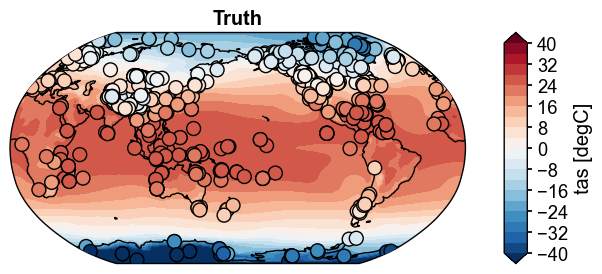

In [28]:
cfr.set_style('journal', font_scale=1.2)
fig, ax = obs.plot(
    levels=np.linspace(-40, 40, 21),
    cbar_kwargs={'ticks': np.linspace(-40, 40, 11)},
    cyclic=True,
    da_target=ds_truth_ann['tas'],
    t_idx=-1,
    title='Truth',
)

## Prior Setup

In [29]:
pm = cfr.PriorMember(ds_prior_ann)
pm.gen_samples_bootstrap(nens=30, clim_yrs=1)
prior = cfr.Prior(pm)
prior.ds

<xarray.Dataset> Size: 2MB
Dimensions:  (lat: 96, lon: 144, ens: 30)
Coordinates:
  * lat      (lat) float32 384B -90.0 -88.11 -86.21 -84.32 ... 86.21 88.11 90.0
  * lon      (lon) float32 576B 0.0 2.5 5.0 7.5 10.0 ... 350.0 352.5 355.0 357.5
Dimensions without coordinates: ens
Data variables:
    tas      (lat, lon, ens) float32 2MB -47.45 -47.06 -48.57 ... -23.29 -20.72

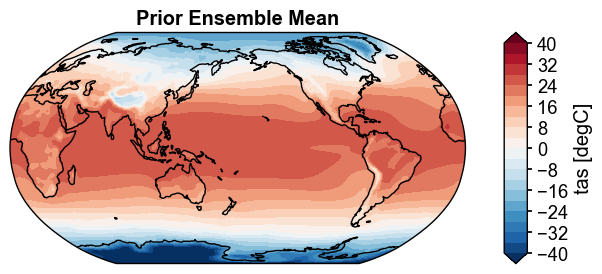

In [30]:
fig, ax = prior.ds['tas'].mean('ens').x.plot(
    levels=np.linspace(-40, 40, 21),
    cbar_kwargs={'ticks': np.linspace(-40, 40, 11)},
    cyclic=True,
    title='Prior Ensemble Mean',
)

## EnKF Solver Setup

In [31]:
prior.ds_rgd = prior.ds.copy()
prior.ds_ann = prior.ds.copy()

da_solver = cfr.enkf.Solver(prior, obs)
da_solver.prep(
    recon_period=(1801, 1850),
    loc_radius=10000,
)

>>> Proxy System Modeling: Y = H(X)
>>> Computing the localization matrix


Processing variables: 100%|██████████| 1/1 [00:00<00:00,  1.90it/s]


In [32]:
# da_solver.run(nproc=1)

In [33]:
%%time
da_solver.run(nproc=4, chunksize=10)

>>> DA update


Updating time slices: 100%|██████████| 50/50 [00:12<00:00,  4.06it/s]

CPU times: user 1.33 s, sys: 2.22 s, total: 3.55 s
Wall time: 12.8 s


In [34]:
os.makedirs('./recons', exist_ok=True)
da_solver.post.to_netcdf(f'./recons/recon_LMR_SNR10_ocn_loc10000.nc')
da_solver.post

<xarray.Dataset> Size: 166MB
Dimensions:  (time: 50, lat: 96, lon: 144, ens: 30)
Coordinates:
  * lat      (lat) float32 384B -90.0 -88.11 -86.21 -84.32 ... 86.21 88.11 90.0
  * lon      (lon) float32 576B 0.0 2.5 5.0 7.5 10.0 ... 350.0 352.5 355.0 357.5
  * time     (time) int64 400B 1801 1802 1803 1804 1805 ... 1847 1848 1849 1850
Dimensions without coordinates: ens
Data variables:
    tas      (time, lat, lon, ens) float64 166MB -53.43 -53.49 ... -23.44 -23.22

## Validation

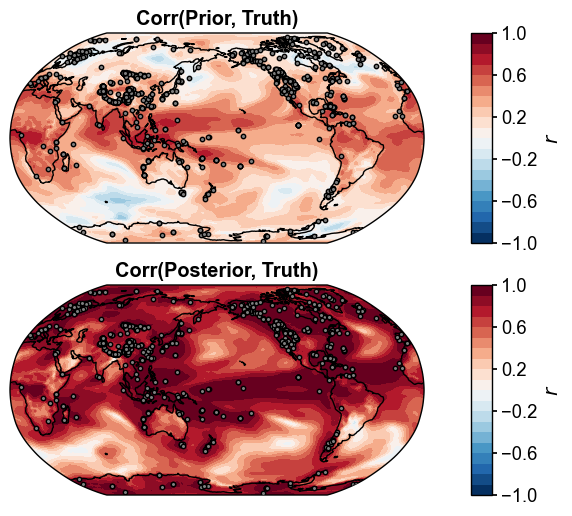

In [35]:
fig, ax =  da_solver.plot_valid(
    ds_truth_ann, ds_prior=ds_prior_ann, vn='tas', metric='corr',
    df_sites=obs.df[['lat', 'lon']],
    site_markersizes=10,
    legend=False,
    cyclic=True,
)

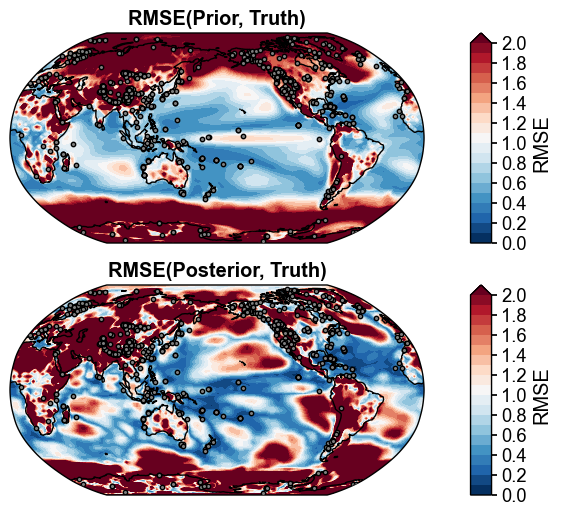

In [36]:
fig, ax =  da_solver.plot_valid(
    ds_truth_ann, ds_prior=ds_prior_ann, vn='tas', metric='RMSE',
    df_sites=obs.df[['lat', 'lon']],
    site_markersizes=10,
    legend=False,
    cyclic=True,
)

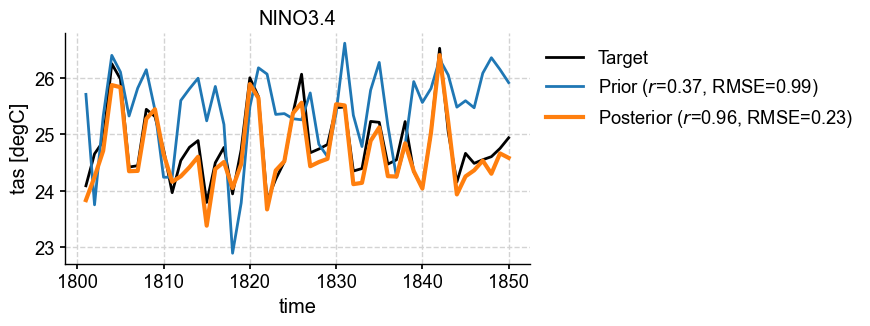

In [37]:
fig, ax =  da_solver.plot_valid(ds_truth_ann, ds_prior=ds_prior_ann, metric='nino3.4')